## **Predicting Carbon Dioxide (CO₂) Emissions Using Socioeconomic and Environmental Indicators: A Machine Learning Analysis of the World Bank World Development Indicators Dataset**

#### *Governments worldwide are working to reduce greenhouse gas emissions while maintaining economic growth. However, economic development, industrialization, energy consumption and population growth often contribute to increased carbon dioxide (CO₂) emissions.*

#### *Understanding which development indicators are most associated with CO₂ emissions can help in designing more a effective climate mitigation strategies.*

#### *This project aims to predict CO₂ emissions using socioeconomic and environmental indicators from the World Bank World Development Indicators (WDI) dataset through machine learning models*

----------------------------------------------------------------------------------------------------------------------------------------------------------

### **Objective**

##### 1. Identify the major development indicators associated with CO₂ emissions.
##### 2. Explore relationships between economic growth, energy use and carbon emissions.
##### 3. Build machine learning models to predict CO₂ emissions..
##### 4. Compare model performance.
##### 5. Provide recommendations for sustainable development.

---------------------------------------------------------------------------------------------------------------------------------------------------------

### **Data preparation**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### **Load the World Bank Dataset and Understand the dataframe**

In [4]:
World_Bank= pd.read_csv('WDICSV.csv')

In [5]:
World_Bank.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.747222,35.240236,NaN,NaN


#### **Data Collection & Understanding**

In [6]:
World_Bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395276 entries, 0 to 395275
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    395276 non-null  object 
 1   Country Code    395276 non-null  object 
 2   Indicator Name  395276 non-null  object 
 3   Indicator Code  395276 non-null  object 
 4   1960            37409 non-null   float64
 5   1961            42744 non-null   float64
 6   1962            44022 non-null   float64
 7   1963            44959 non-null   float64
 8   1964            45461 non-null   float64
 9   1965            47288 non-null   float64
 10  1966            47548 non-null   float64
 11  1967            48180 non-null   float64
 12  1968            48780 non-null   float64
 13  1969            49561 non-null   float64
 14  1970            72414 non-null   float64
 15  1971            76752 non-null   float64
 16  1972            78457 non-null   float64
 17  1973      

In [7]:
World_Bank.shape

(395276, 70)

In [8]:
World_Bank.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='object')

In [9]:
World_Bank.describe(include='all')

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,395276,395276,395276,395276,3.740900e+04,4.274400e+04,4.402200e+04,4.495900e+04,4.546100e+04,4.728800e+04,...,2.228010e+05,2.206780e+05,2.198260e+05,2.168130e+05,2.141940e+05,2.089640e+05,1.942610e+05,1.773140e+05,1.385160e+05,2.260300e+04
unique,266,266,1486,1486,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1486,1486,266,266,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.857346e+12,1.730549e+12,1.775442e+12,1.843710e+12,1.996568e+12,2.227595e+12,...,5.909670e+12,6.307522e+12,6.573235e+12,3.171583e+13,3.879949e+14,2.073713e+15,1.588806e+16,6.172488e+16,1.758771e+17,9.806782e+10
std,NaN,NaN,NaN,NaN,9.536652e+13,9.625841e+13,1.011836e+14,1.070260e+14,1.159004e+14,1.325637e+14,...,4.027233e+14,4.246206e+14,4.115903e+14,1.158567e+16,1.759882e+17,9.434647e+17,6.996798e+18,2.598402e+19,6.544729e+19,2.665302e+12
min,NaN,NaN,NaN,NaN,-6.983892e+14,-1.048260e+15,-1.190074e+15,-1.321699e+15,-1.403476e+15,-1.815444e+15,...,-3.970130e+14,-4.306058e+14,-4.421837e+14,-3.551874e+15,-6.131892e+15,-4.608969e+14,-5.290986e+14,-3.846495e+15,-1.067341e+16,-3.535408e+06
25%,NaN,NaN,NaN,NaN,4.463477e+00,4.522474e+00,4.587562e+00,4.666956e+00,4.748772e+00,4.509493e+00,...,5.250000e+00,5.674032e+00,5.198045e+00,5.400000e+00,5.348262e+00,5.882489e+00,5.853841e+00,5.998129e+00,6.000000e+00,9.962139e+00
50%,NaN,NaN,NaN,NaN,3.634980e+01,3.737967e+01,3.644394e+01,3.590500e+01,3.688600e+01,3.699231e+01,...,3.891047e+01,4.174238e+01,3.900000e+01,4.000000e+01,4.080603e+01,4.125892e+01,4.345239e+01,4.669270e+01,4.512540e+01,3.178229e+01
75%,NaN,NaN,NaN,NaN,8.938900e+04,7.811850e+04,6.977029e+04,6.960000e+04,8.000000e+04,1.100920e+05,...,6.710000e+03,9.500000e+03,9.234425e+03,1.183000e+04,1.211167e+04,1.334150e+04,1.752680e+04,3.233278e+04,1.819350e+04,6.170000e+01


### Let's discover the exact names of the indicators.

In [10]:
# The number of indicator names in the WDI Dataset
World_Bank['Indicator Name'].nunique()

1486

In [11]:
# display the indicator names, pick at random
World_Bank['Indicator Name'].sample(30, random_state=42)

352786    Households and NPISHs Final consumption expend...
355491    Diarrhea treatment (% of children under 5 rece...
224253    Tariff rate, most favored nation, weighted mea...
131277                                    GDP (current US$)
262834    Self-employed, female (% of female employment)...
172899             GDP, PPP (constant 2021 international $)
300472    CPIA efficiency of revenue mobilization rating...
253221    Households and NPISHs Final consumption expend...
190760                     Goods imports (BoP, current US$)
116370    Financial intermediary services indirectly Mea...
48700     Prevalence of anemia among women of reproducti...
29049     Methane (CH4) emissions (total) excluding LULU...
181387    Automated teller machines (ATMs) (per 100,000 ...
96986     Employment in industry, male (% of male employ...
236112    Statistical performance indicators (SPI): Pill...
35369            Primary income receipts (BoP, current US$)
290511               Life expectancy at 

#### *Find the indicators needed*

In [12]:
# pick only names with CO₂ emissions
World_Bank[World_Bank['Indicator Name'].str.contains('CO2', case=False, na=False)]['Indicator Name'].unique()

array(['Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
       'Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Power Industry (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Waste (Mt CO2e)',
       'Carbon dioxide (CO2) net fluxes from LULUCF - Deforestation (Mt CO2e)',
       'Carbon dioxide (CO2) net fluxes from LULUCF - Forest Land

In [13]:
# pick names with GDP per capital
World_Bank[World_Bank['Indicator Name'].str.contains('GDP per capita', case=False, na=False)]['Indicator Name'].unique()

array(['GDP per capita (constant 2015 US$)',
       'GDP per capita (constant LCU)', 'GDP per capita (current LCU)',
       'GDP per capita (current US$)', 'GDP per capita growth (annual %)',
       'GDP per capita, PPP (constant 2021 international $)',
       'GDP per capita, PPP (current international $)',
       'Government expenditure per student, primary (% of GDP per capita)',
       'Government expenditure per student, secondary (% of GDP per capita)',
       'Government expenditure per student, tertiary (% of GDP per capita)'],
      dtype=object)

In [14]:
# find the Energy use
World_Bank[World_Bank['Indicator Name'].str.contains('Energy use', case=False, na=False)]['Indicator Name'].unique()

array(['Alternative and nuclear energy (% of total energy use)',
       'Energy imports, net (% of energy use)',
       'Energy use (kg of oil equivalent per capita)',
       'Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)',
       'GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent)',
       'GDP per unit of energy use (PPP $ per kg of oil equivalent)'],
      dtype=object)

In [15]:
# Find the electricity
World_Bank[World_Bank['Indicator Name'].str.contains('electricity', case=False, na=False)]['Indicator Name'].unique()

array(['Access to electricity (% of population)',
       'Access to electricity, rural (% of rural population)',
       'Access to electricity, urban (% of urban population)',
       'Electricity production from coal sources (% of total)',
       'Electricity production from hydroelectric sources (% of total)',
       'Electricity production from natural gas sources (% of total)',
       'Electricity production from nuclear sources (% of total)',
       'Electricity production from oil sources (% of total)',
       'Electricity production from oil, gas and coal sources (% of total)',
       'Electricity production from renewable sources, excluding hydroelectric (% of total)',
       'Electricity production from renewable sources, excluding hydroelectric (kWh)',
       'Renewable electricity output (% of total electricity output)'],
      dtype=object)

In [16]:
# Find the urban poplulation
World_Bank[World_Bank['Indicator Name'].str.contains('Urban population', case=False, na=False)]['Indicator Name'].unique()

array(['Access to clean fuels and technologies for cooking, urban (% of urban population)',
       'Access to electricity, urban (% of urban population)',
       'People practicing open defecation, urban (% of urban population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services, urban (% of urban population)',
       'People using safely managed drinking water services, urban (% of urban population)',
       'People using safely managed sanitation services, urban (% of urban population)',
       'People with basic handwashing facilities including soap and water, urban (% of urban population)',
       'Population in the largest city (% of urban population)',
       'Population living in slums (% of urban population)',
       'Urban population', 'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'Urban population living in areas where elevation 

In [17]:
# find Renewable energy
World_Bank[World_Bank['Indicator Name'].str.contains('Renewable energy', case=False, na=False)]['Indicator Name'].unique()

array(['Renewable energy consumption (% of total final energy consumption)'],
      dtype=object)

In [18]:
World_Bank[
    World_Bank['Indicator Name'].str.contains('Forest area', case=False, na=False)
]['Indicator Name'].unique()

array(['Forest area (% of land area)', 'Forest area (sq. km)'],
      dtype=object)

#### how many countries have data and how many missing values there are

In [19]:
selected_indicators = [
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)",
    "GDP per capita (current US$)",
    "Energy use (kg of oil equivalent per capita)",
    "Access to electricity (% of population)",
    "Urban population (% of total population)",
    'Renewable energy consumption (% of total final energy consumption)',
    'Forest area (% of land area)'
]

In [20]:
df = World_Bank[
    World_Bank["Indicator Name"].isin(selected_indicators)
]

df = df[["Country Name", "Indicator Name", "2023"]]

df.head()

,Country Name,Indicator Name,2023
3,Africa Eastern and Southern,Access to electricity (% of population),50.667516
176,Africa Eastern and Southern,Carbon dioxide (CO2) emissions excluding LULUC...,0.838104
414,Africa Eastern and Southern,Energy use (kg of oil equivalent per capita),565.221624
500,Africa Eastern and Southern,Forest area (% of land area),NaN
516,Africa Eastern and Southern,GDP per capita (current US$),1571.449189


In [21]:
df_wide = df.pivot(
    index="Country Name",
    columns="Indicator Name",
    values="2023"
)

df_wide.reset_index(inplace=True)

df_wide.head()

Indicator Name,Country Name,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),GDP per capita (current US$),Renewable energy consumption (% of total final energy consumption),Urban population (% of total population)
0,Afghanistan,85.300000,0.280995,NaN,1.852782,413.757895,NaN,25.473053
1,Africa Eastern and Southern,50.667516,0.838104,565.221624,NaN,1571.449189,NaN,37.772301
2,Africa Western and Central,57.069267,0.494008,344.391921,NaN,1841.855064,NaN,52.282908
3,Albania,100.000000,1.749144,888.463856,28.791971,9730.869219,NaN,58.210609
4,Algeria,100.000000,4.128275,1503.414066,0.830314,5370.477235,NaN,74.732808


In [22]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 8 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Country Name                                                                266 non-null    object 
 1   Access to electricity (% of population)                                     263 non-null    float64
 2   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  251 non-null    float64
 3   Energy use (kg of oil equivalent per capita)                                193 non-null    float64
 4   Forest area (% of land area)                                                213 non-null    float64
 5   GDP per capita (current US$)                                                251 non-null    float64
 6   Renewable energy consumption (% of total final ener

### **Handling Missing data**

In [23]:
# displace all the contrt list
df_wide["Country Name"].tolist()

['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean small states',
 'Cayman Islands',
 'Central African Republic',
 'Central Europe and the Baltics',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Early-demographic dividend',
 'East

### Check missing values

In [24]:
df_wide.isnull().sum()

Indicator Name
Country Name                                                                    0
Access to electricity (% of population)                                         3
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)     15
Energy use (kg of oil equivalent per capita)                                   73
Forest area (% of land area)                                                   53
GDP per capita (current US$)                                                   15
Renewable energy consumption (% of total final energy consumption)            266
Urban population (% of total population)                                        1
dtype: int64

### Remove regional aggregates

In [25]:
aggregates = [
    "Africa Eastern and Southern",
    "Africa Western and Central",
    "Arab World",
    "Caribbean small states",
    "Central Europe and the Baltics",
    "Early-demographic dividend",
    "East Asia & Pacific",
    "East Asia & Pacific (IDA & IBRD countries)",
    "East Asia & Pacific (excluding high income)",
    "Euro area",
    "Europe & Central Asia",
    "Europe & Central Asia (IDA & IBRD countries)",
    "Europe & Central Asia (excluding high income)",
    "European Union",
    "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)",
    "High income",
    "IBRD only",
    "IDA & IBRD total",
    "IDA blend",
    "IDA only",
    "IDA total",
    "Late-demographic dividend",
    "Latin America & Caribbean",
    "Latin America & Caribbean (excluding high income)",
    "Latin America & the Caribbean (IDA & IBRD countries)",
    "Least developed countries: UN classification",
    "Low & middle income",
    "Low income",
    "Lower middle income",
    "Middle income",
    "North America",
    "Not classified",
    "OECD members",
    "Other small states",
    "Pacific island small states",
    "Post-demographic dividend",
    "Pre-demographic dividend",
    "Small states",
    "South Asia",
    "South Asia (IDA & IBRD)",
    "Sub-Saharan Africa",
    "Sub-Saharan Africa (IDA & IBRD countries)",
    "Sub-Saharan Africa (excluding high income)",
    "Upper middle income",
    "World",
    "Middle East, North Africa, Afghanistan & Pakistan",
    "Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",
    "Middle East, North Africa, Afghanistan & Pakistan (excluding high income)"
]

df_wide = df_wide[~df_wide["Country Name"].isin(aggregates)]

print(df_wide.shape)

(217, 8)


In [26]:
df_wide.isnull().sum()

Indicator Name
Country Name                                                                    0
Access to electricity (% of population)                                         2
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)     14
Energy use (kg of oil equivalent per capita)                                   68
Forest area (% of land area)                                                    4
GDP per capita (current US$)                                                   14
Renewable energy consumption (% of total final energy consumption)            217
Urban population (% of total population)                                        0
dtype: int64

In [27]:
missing = pd.DataFrame({
    "Missing Values": df_wide.isnull().sum(),
    "Percentage": (df_wide.isnull().mean() * 100).round(2)
})

missing

,Missing Values,Percentage
Indicator Name,,
Country Name,0,0.00
Access to electricity (% of population),2,0.92
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),14,6.45
Energy use (kg of oil equivalent per capita),68,31.34
Forest area (% of land area),4,1.84
GDP per capita (current US$),14,6.45
Renewable energy consumption (% of total final energy consumption),217,100.00
Urban population (% of total population),0,0.00


#### **Data Cleaning**

#### Renewable energy consumption contains 100% missing values for 2023 and therefore cannot contribute to the analysis. It will be removed.

In [28]:
# Remove the renewable energy column
df_model = df_wide.drop(
    columns=["Renewable energy consumption (% of total final energy consumption)"]
)

# Remove rows where the target is missing
df_model = df_model.dropna(
    subset=["Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"]
)

# Fill missing predictor values with the median
predictors = [
    "Access to electricity (% of population)",
    "Energy use (kg of oil equivalent per capita)",
    "Forest area (% of land area)",
    "GDP per capita (current US$)",
    "Urban population (% of total population)"
]

for col in predictors:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Confirm all missing values are handled
df_model.isnull().sum()

Indicator Name
Country Name                                                                  0
Access to electricity (% of population)                                       0
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)    0
Energy use (kg of oil equivalent per capita)                                  0
Forest area (% of land area)                                                  0
GDP per capita (current US$)                                                  0
Urban population (% of total population)                                      0
dtype: int64

In [29]:
df_model.head()

Indicator Name,Country Name,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),GDP per capita (current US$),Urban population (% of total population)
0,Afghanistan,85.3,0.280995,1467.109319,1.852782,413.757895,25.473053
3,Albania,100.0,1.749144,888.463856,28.791971,9730.869219,58.210609
4,Algeria,100.0,4.128275,1503.414066,0.830314,5370.477235,74.732808
5,American Samoa,100.0,0.002104,1467.109319,85.200000,7309.929761,81.372154
7,Angola,51.1,0.743839,448.870903,52.091270,2916.136633,69.851503


In [30]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203 entries, 0 to 265
Data columns (total 7 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Country Name                                                                203 non-null    object 
 1   Access to electricity (% of population)                                     203 non-null    float64
 2   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  203 non-null    float64
 3   Energy use (kg of oil equivalent per capita)                                203 non-null    float64
 4   Forest area (% of land area)                                                203 non-null    float64
 5   GDP per capita (current US$)                                                203 non-null    float64
 6   Urban population (% of total population)                

In [31]:
print(df_model.shape)

(203, 7)


#### **Exploratory Data Analysis (EDA) and machine learning**

#### Summary Statistics

In [32]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
Indicator Name,,,,,,,,
Access to electricity (% of population),203.0,87.949261,22.168851,11.600000,87.300000,100.000000,100.000000,100.000000
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),203.0,4.501921,7.674953,0.000000,0.690656,2.529670,5.080993,78.857111
Energy use (kg of oil equivalent per capita),203.0,2040.263683,2267.094091,154.996261,895.004351,1467.109319,2173.654774,16343.040405
Forest area (% of land area),203.0,32.402219,24.095018,0.000000,11.417597,32.382738,49.919274,94.447584
GDP per capita (current US$),203.0,18654.505703,25116.006287,250.627253,2897.552713,7309.929761,23181.566276,133230.619179
Urban population (% of total population),203.0,62.190884,22.685233,15.058102,43.125434,63.582371,79.521895,100.000000


#### Check for Outliers

In [33]:
numeric_cols = df_wide.select_dtypes(include="number").columns
print(numeric_cols)

Index(['Access to electricity (% of population)',
       'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
       'Energy use (kg of oil equivalent per capita)',
       'Forest area (% of land area)', 'GDP per capita (current US$)',
       'Renewable energy consumption (% of total final energy consumption)',
       'Urban population (% of total population)'],
      dtype='object', name='Indicator Name')


In [34]:
print(df_wide[numeric_cols].shape)

(217, 7)


In [35]:
df_wide[numeric_cols].isnull().sum()

Indicator Name
Access to electricity (% of population)                                         2
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)     14
Energy use (kg of oil equivalent per capita)                                   68
Forest area (% of land area)                                                    4
GDP per capita (current US$)                                                   14
Renewable energy consumption (% of total final energy consumption)            217
Urban population (% of total population)                                        0
dtype: int64

In [36]:
numeric_cols = df_wide.select_dtypes(include="number").columns

In [37]:
numeric_cols = (
    df_wide
    .select_dtypes(include="number")
    .dropna(axis=1, how="all")
    .columns
)

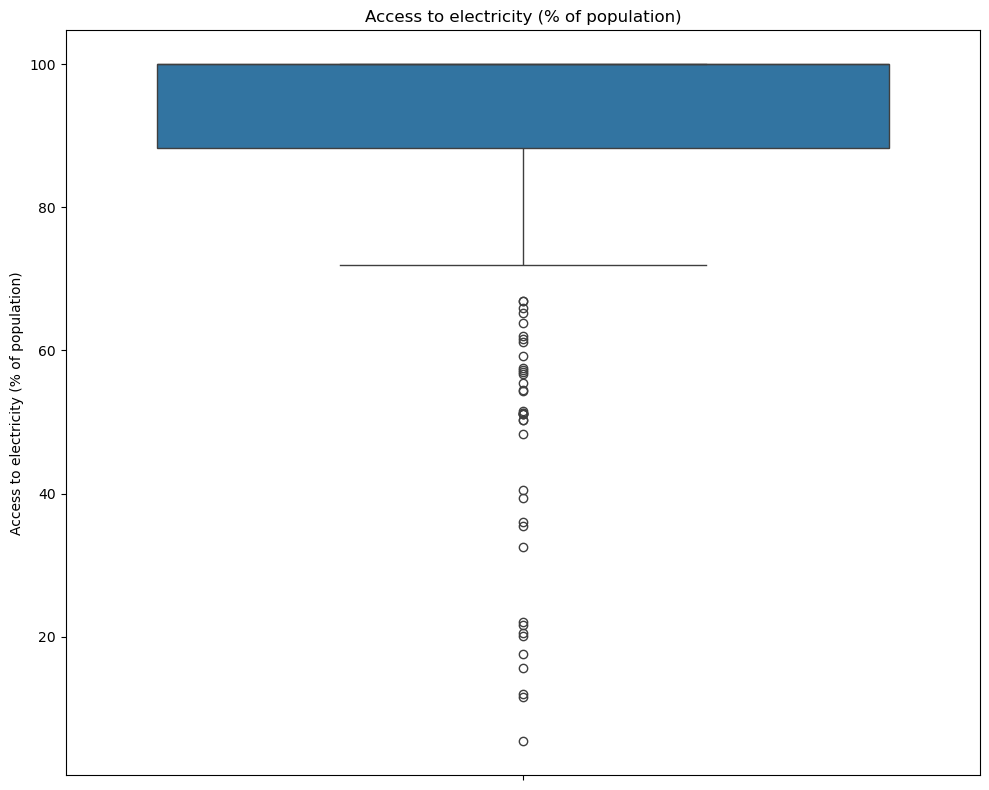

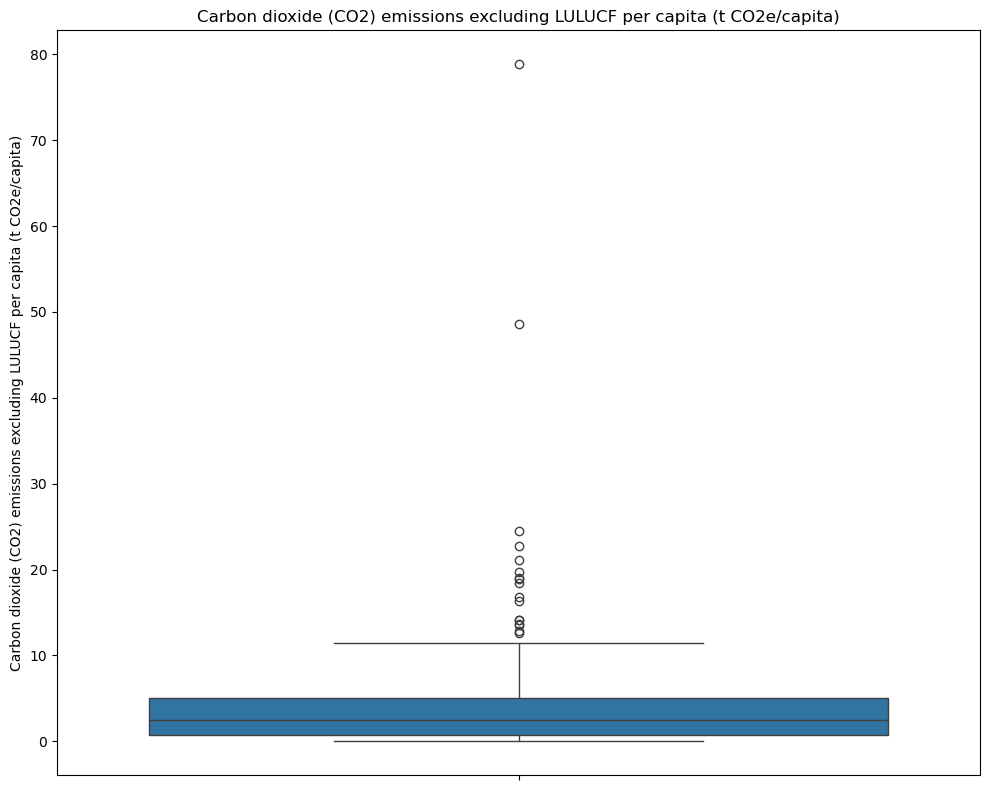

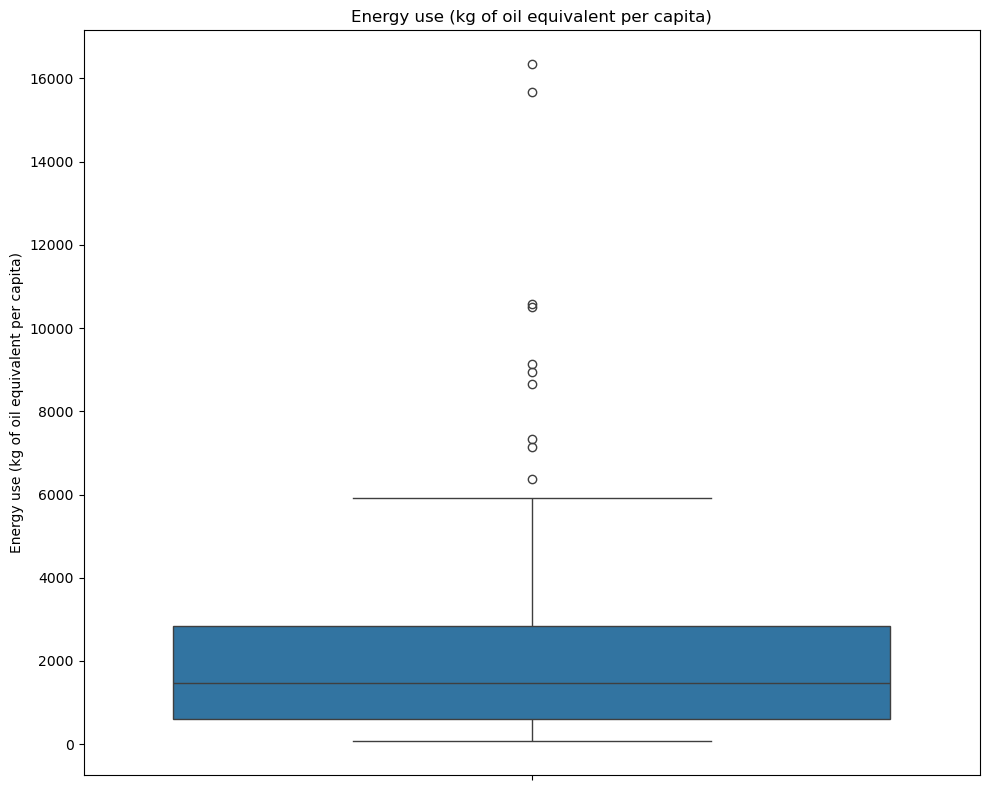

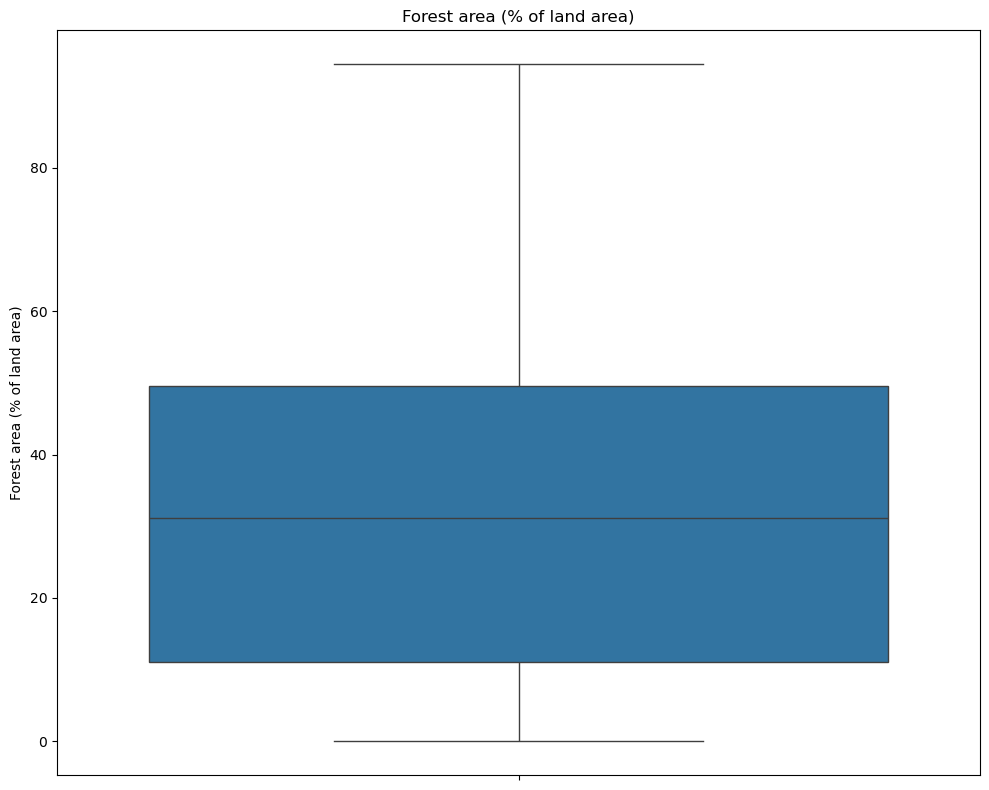

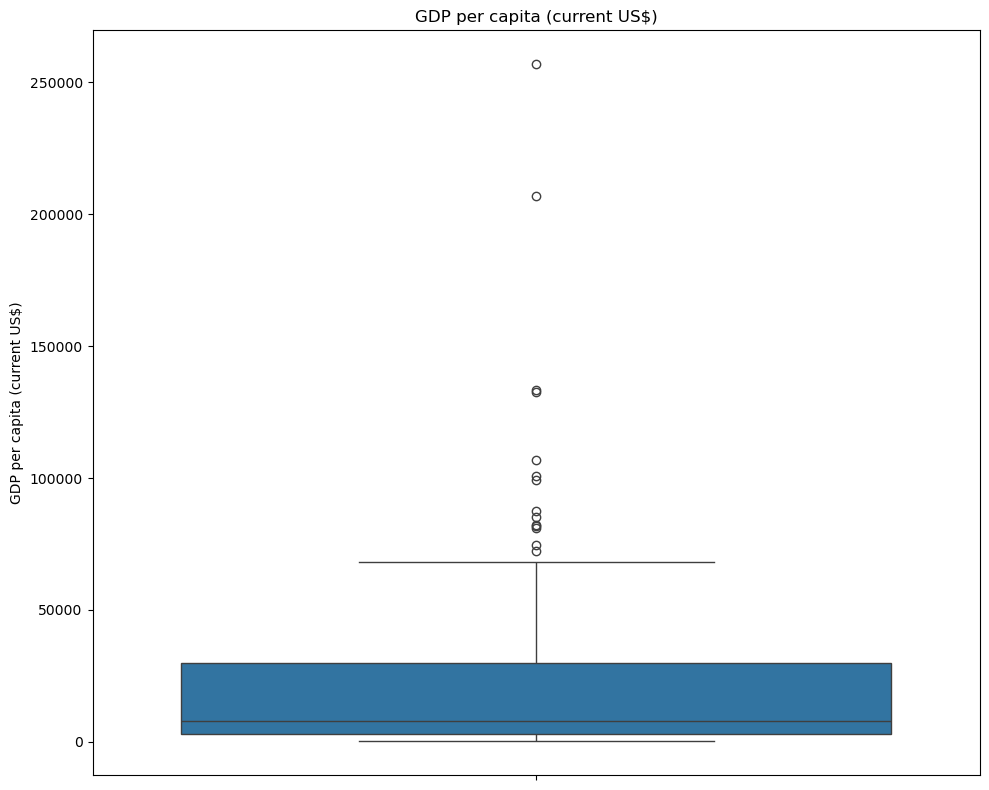

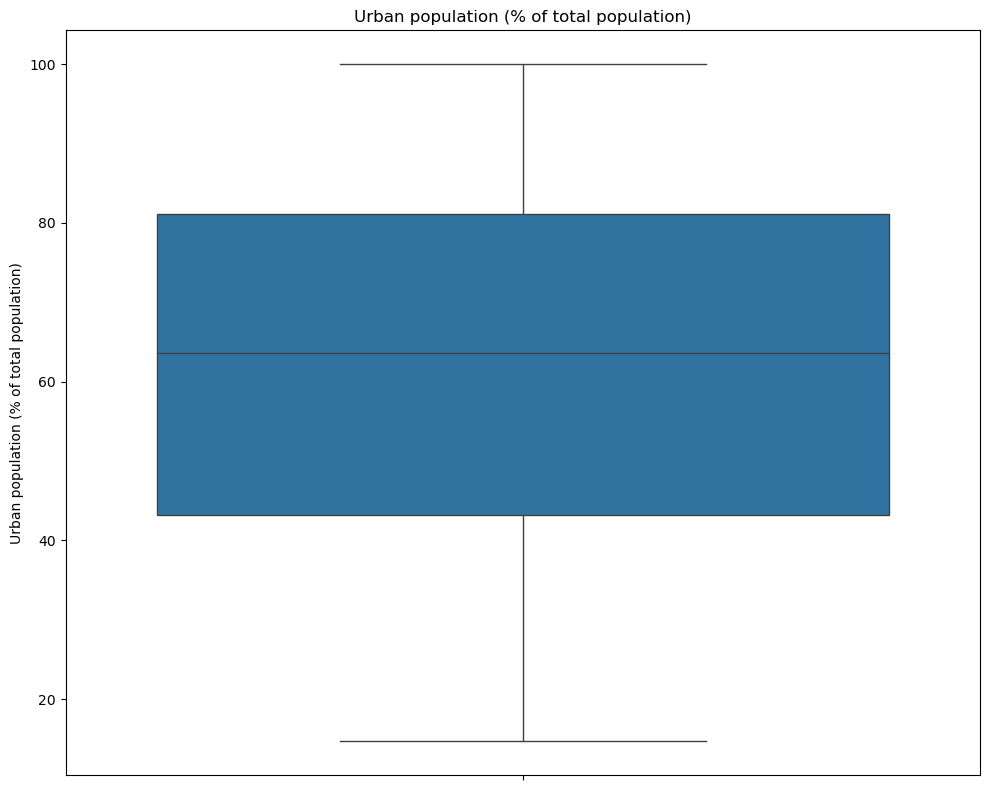

In [38]:
for col in numeric_cols:
    plt.figure(figsize=(10,8))
    sns.boxplot(y=df_wide[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

#### Distribution of Variables

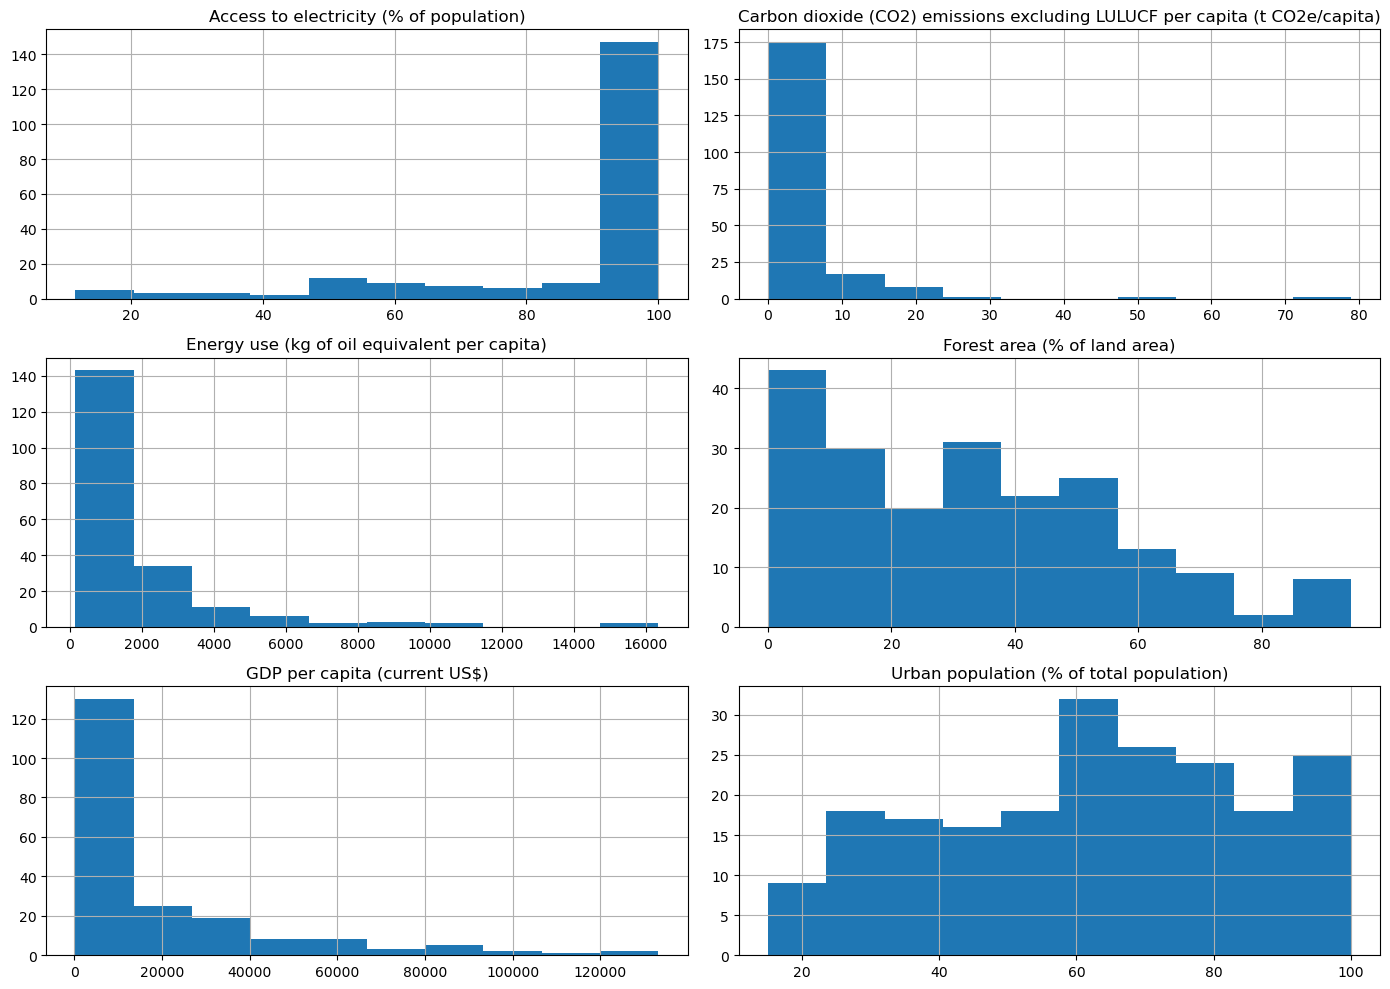

In [39]:
df_model.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

#### Correlation Heatmap

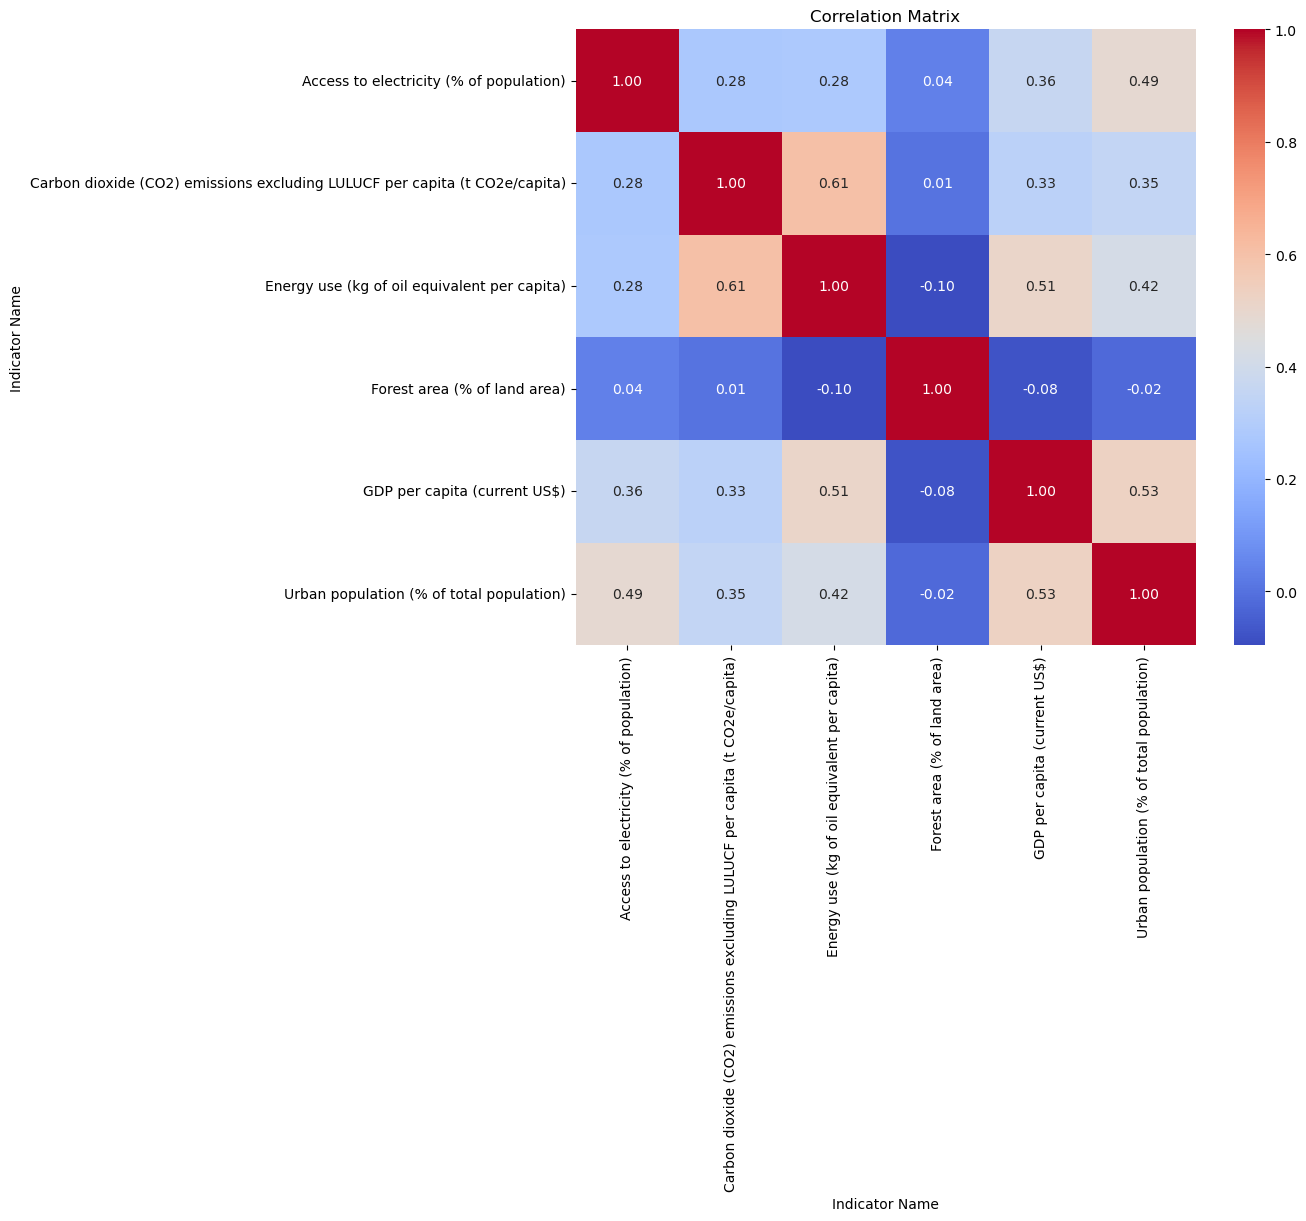

In [40]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    df_model.drop(columns="Country Name").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

#### Scatter Plot: GDP vs CO₂

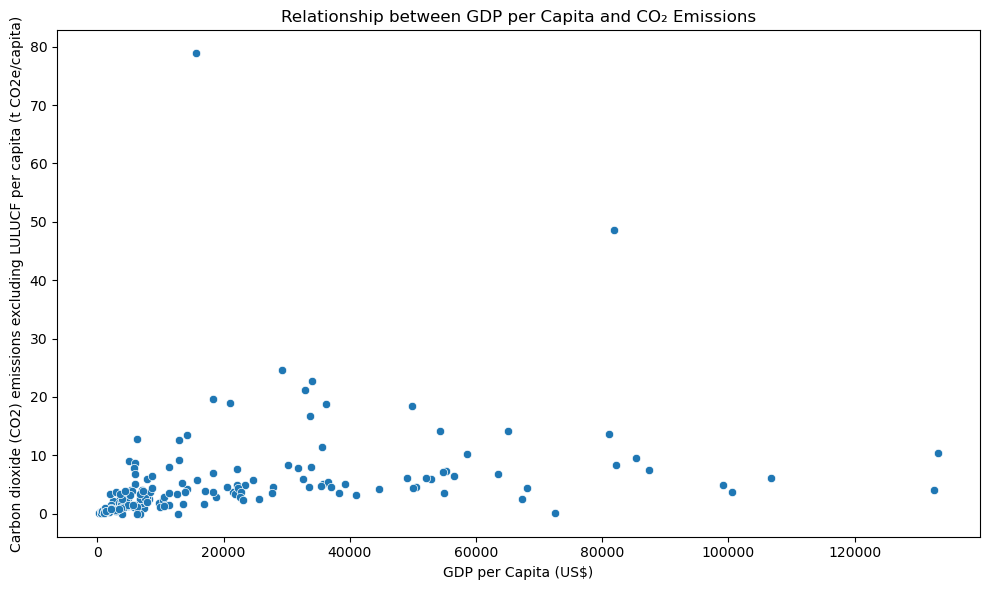

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_wide,
    x="GDP per capita (current US$)",
    y="Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
)

plt.xlabel("GDP per Capita (US$)")
plt.ylabel("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)")
plt.title("Relationship between GDP per Capita and CO₂ Emissions")

plt.tight_layout()

plt.show()

### Scatter Plot: Energy Use vs CO₂

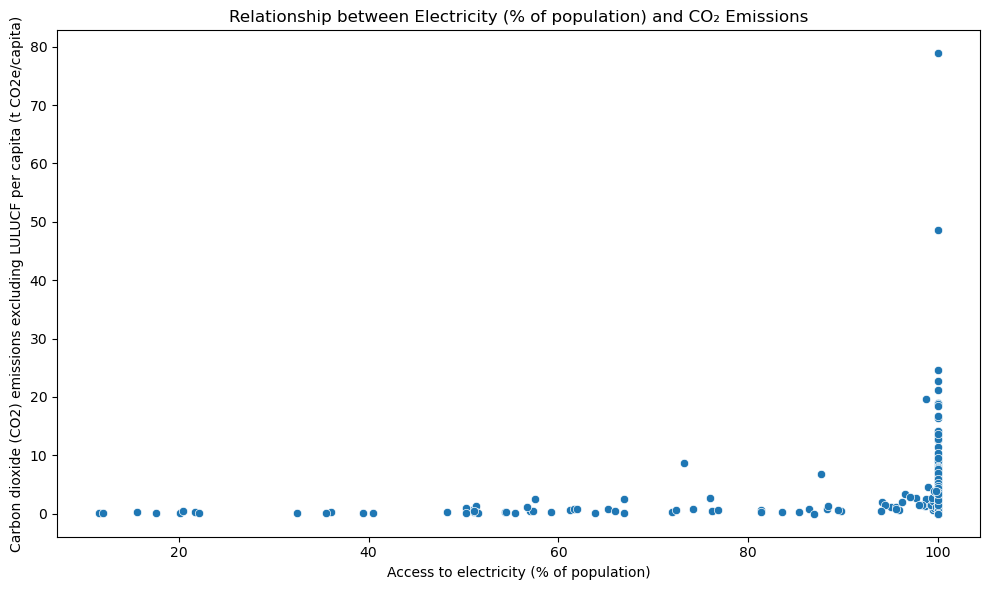

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_model,
    x="Access to electricity (% of population)",
    y="Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
)

plt.xlabel("Access to electricity (% of population)")
plt.ylabel("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)")
plt.title("Relationship between Electricity (% of population) and CO₂ Emissions")

plt.tight_layout()

plt.show()

#### Scatter Plot: Electricity Access vs CO₂

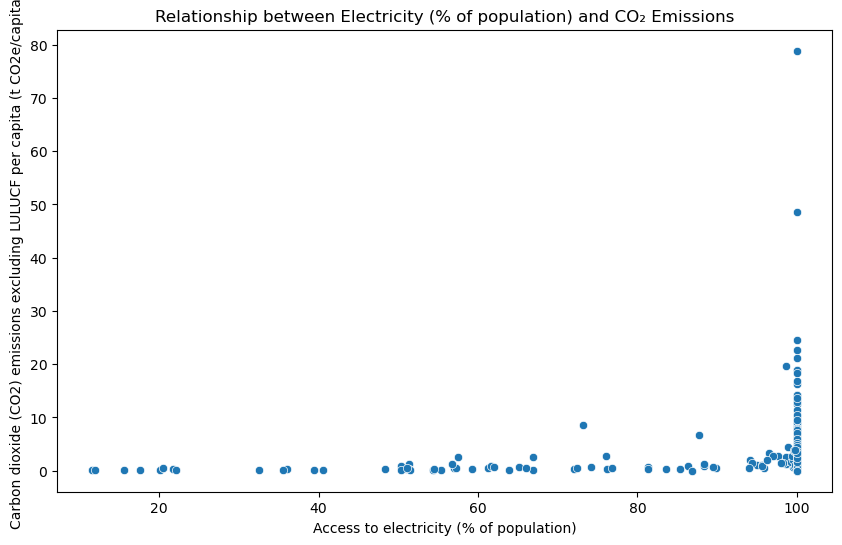

In [43]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_model,
    x="Access to electricity (% of population)",
    y="Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
)
plt.title("Relationship between Electricity (% of population) and CO₂ Emissions")
plt.show()

Energy use per capita has the strongest positive relationship with CO₂ emissions (r = 0.61), suggesting that countries consuming more energy generally emit more carbon dioxide. GDP per capita, urban population, and access to electricity show moderate positive relationships, whereas forest area exhibits almost no linear relationship with CO₂ emissions.

#### **Machine Learning Modeling**

Prepare the data

In [44]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[
    "Country Name",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
])

y = df_model["Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"]

Train-test split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model 1 (Linear Regression)

In [46]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Evaluate

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_lr)

mse = mean_squared_error(y_test, pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, pred_lr)

print(mae)
print(rmse)
print(r2)

1.6923144362662126
2.1738986930584714
0.516752819370822


Model 2

In [48]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Compare models

In [49]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],
    "R²":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.692314,2.173899,0.516753
1,Random Forest,2.711632,7.429244,-4.643909


#### **Model Evaluation**

Two regression models were developed to predict per capita CO₂ emissions using development indicators. Linear Regression achieved the best performance with an MAE of 1.69, RMSE of 2.17 and an R² score of 0.52. This indicates that the model explained approximately 52% of the variation in CO₂ emissions across countries.

Random Forest Regressor performed considerably worse, producing an MAE of 2.71, RMSE of 7.43, and a negative R² score (-4.64). The poor performance suggests that the model did not generalize well to unseen data, likely due to the relatively small dataset and limited number of predictor variables.

Based on the evaluation metrics, Linear Regression was selected as the final model because it achieved the lowest prediction errors and the highest R² score.

#### **Key Findings**

1. Energy use showed the strongest positive relationship with CO₂ emissions.
2. GDP per capita had a moderate positive relationship with CO₂ emissions.
3. Urban population also showed a positive association with CO₂ emissions.
4. Forest area had a weak relationship with CO₂ emissions.
5. Linear Regression outperformed Random Forest for this dataset.

#### **Conclusion**

This study demonstrated that socioeconomic and environmental indicators from the World Bank World Development Indicators dataset can be used to predict national CO₂ emissions. Among the models tested, Linear Regression provided the most reliable predictions, explaining approximately 52% of the variation in CO₂ emissions. The findings highlight the importance of energy consumption, economic development and urbanization in influencing carbon emissions and provide useful insights for evidence-based environmental policy.

#### **Recommendation**

1. Increase investment in renewable energy sources.
2. Encourage low-carbon urban planning.
3. Improve environmental monitoring and reporting.
4. Collect more complete development indicator data to improve future prediction models.

#### **Save the model**

In [ ]:
import joblib

joblib.dump(lr, "linear_regression_model.pkl")

#### **Save the predictor names**

In [ ]:
predictors = [
    "Access to electricity (% of population)",
    "Energy use (kg of oil equivalent per capita)",
    "Forest area (% of land area)",
    "GDP per capita (current US$)",
    "Urban population (% of total population)"
]

joblib.dump(predictors, "predictors.pkl")

#### **Save the predictor names**

In [ ]:
medians = df_model[predictors].median()

joblib.dump(medians, "medians.pkl")

save country names

In [ ]:
df_model.to_csv("country_data.csv", index=False)